
# Mini Proyecto – Análisis Estadístico CWL (Clash of Clans)

**Dataset:** Los datasets que he metido al proyecto son 10 meses de las ultimas ligas disputadas por uno de mis equipos de clash of clans.

**Tipo de análisis:** Realizaremos un analisis estadistico del rendimiento de los jugadores y del clan en liga.

**Obtencion de los datasets:** Mediante la utilizacion de un bot en discord obtenemos los datos de cada liga al finalizar las mismas, las descargas se realizan en formato excel y viene un documento con 8 hojas de excel , lo cual solamente nos quedamos con la que 
engloba todas las estadisticas de rendimiento en la liga. Eliminamos las hojas que no vamos a utilizar en el proyecto, guardamos en formato ut8 desde el excel y a continuacion venimos a discord a eliminar los caracteres que no nos interesan con control +f y la expresion
que nos realiza esta limpieza : [^\x00-\x7F]+ . Despues para asegurarnos de que guarda bien en la parte de abajo le damos save with encoding y volvemos a elegir utf8.

**Explicacion del videojuego para facilitar analisis:** Desde cada dia 2 o 3 de cada mes se inicia un torneo de clanes en los que te emparejan con otros 7 rivales con los que jugaras a lo largo de la semana. Las ligas son de 15 o de 30 dependiendo de cuantos miembros tengas en el clan en ese momento. El sistema es de ascenso o descenso hasta la primera liga que sería campeones 1. En un clan de nivel alto lo normal es que los ataques ronden el 90 % de destruccion y una media superior a las 2.5 estrellas.

**Objetivo:**  
Analizar el rendimiento ofensivo y defensivo de los jugadores, asi como los rivales a los que atacan en funcion de su posicionamiento.
En un principio como no sabía como iba a ser el proyecto me parecia una idea interesante ya que el analisis que puedes obtener de unos datos asi 
te puede ofrecer unas buenas estadisticas acerca de la guerra.


## PARTE 1: Análisis Descriptivo (Dataset Propio)



## 1. Carga de librerías y datasets
- Uso de pandas para análisis de datos
- Uso de matplotlib para visualización
- Unión de varios meses de CWL en un único dataset


In [2]:
# Importamos las librerías necesarias, en esta celda juntamos los 10 datasets en un dataframe y los leemos con un separador ya que vienen separados por punto y coma.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose


""""   DEJO COMENTADA ESTA PARTE PORQUE ES LA EXPLICACION DE COMO HE UNIDO LOS DATASETS. COMO SOLO VOY A ADJUNTAR EL DATASET FINAL ESTA PARTE DE CODIGO ES INNECESARIA EJECUTARLA ASI QUE SE QUEDA COMENTADA.
files = [
    "mayoClash.csv",
    "junioClash.csv",
    "julioClash.csv",
    "agostoClash.csv",
    "septiembreClash.csv",
    "octubreClash.csv",
    "noviembreClash.csv",
    "diciembreClash.csv",
    "eneroClash.csv",
    "febreroClash.csv"
]

dfs = [pd.read_csv(f, sep=";") for f in files]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_csv("clash_all.csv", index=False)
"""
dfClash = pd.read_csv("clash_all.csv")
dfClash.head()


,Name,Tag,Town Hall,Wars Participated,Number of Attacks,Attack Percentage,Total Stars,Avg. Stars,True Stars,Avg. True Stars,...,Defensive Stars,Avg. Defensive Stars,Total Defensive Destruction,Avg Defensive Destruction,Lower TH Hits (Dips),Upper TH Hits (Reaches),Avg. Target Position,Avg. Target Distance,cwl_month,cwl_year
0,(xiao),#YQCQYRQC,18.0,7.0,7.0,100,20.0,"2,86",20.0,"2,86",...,13.0,"2,17",539.0,"89,83",0.0,0.0,8,"-0,57",Mayo,2025
1,Joselillo13,#9R0V0L0Q,18.0,6.0,6.0,100,18.0,3,18.0,3,...,13.0,"2,60",477.0,"95,40",0.0,0.0,"10,17","0,33",Mayo,2025
2,Tidus,#LV9RVGPU,18.0,7.0,7.0,100,17.0,"2,43",17.0,"2,43",...,15.0,"2,50",592.0,"98,67",0.0,0.0,"3,57","-1,71",Mayo,2025
3,maldito,#QLGLRLCQ,18.0,7.0,7.0,100,16.0,"2,29",16.0,"2,29",...,14.0,"2,33",508.0,"84,67",0.0,0.0,"3,86","-0,43",Mayo,2025
4,AskerosoMilwoky,#8GYCVQGPC,18.0,6.0,6.0,100,16.0,"2,67",16.0,"2,67",...,15.0,"2,50",569.0,"94,83",0.0,0.0,"11,50","-0,50",Mayo,2025



## 2. Análisis inicial del dataset
- Dimensiones del dataset combinado
- Tipos de datos
- Valores nulos


In [3]:
# Mostramos las columnas y las filas que tiene el dataset. La decision tomada de añadir otros meses es porque en uno solo el analisis se quedaba bastante escaso.
dfClash.shape

(306, 28)

In [4]:
# Obtenemos informacion detallada del dataframe, observamos que la mayoria de datos son numericos, lo que nos ofrecera cosas interesantes a la hora de analizar.
dfClash.info()

<class 'pandas.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Name                         306 non-null    str    
 1   Tag                          306 non-null    str    
 2   Town Hall                    306 non-null    float64
 3   Wars Participated            306 non-null    float64
 4   Number of Attacks            306 non-null    float64
 5   Attack Percentage            306 non-null    str    
 6   Total Stars                  306 non-null    float64
 7   Avg. Stars                   306 non-null    str    
 8   True Stars                   306 non-null    float64
 9   Avg. True Stars              304 non-null    str    
 10  Total Dest                   306 non-null    float64
 11  Avg Dest                     306 non-null    str    
 12  Three Stars                  306 non-null    float64
 13  Two Stars                    30

## Clasificación de variables del dataset

### Variables nominales
Las variables nominales identifican categorías sin orden entre ellas.

- **Player Name**: identifica al jugador con su nombre en el juego.
- **Tag Name**: tag que identifica a los jugadores.
- **Month**: aunque representa tiempo, se trata como etiqueta categórica cuando se usa para agrupar.

### Variables ordinales
Las variables ordinales representan categorías con un orden lógico, aunque la distancia entre categorías no sea numéricamente interpretable.

- **Town Hall**: el nivel de ayuntamiento indica un orden entre los ayuntamientos y su posible posicionamiento.

### Variables discretas
Las variables discretas tienen valores enteros y representan conteos.

- **Wars Participated**: número de guerras en las que participa un jugador.
- **Number of Attacks**: total de ataques realizados.
- **Total Stars**: número total de estrellas obtenidas.
- **Three Stars**, **Two Stars**, **One Star**, **Zero Stars**: conteo de resultados por tipo de ataque.
- **Missed Attacks**: número de ataques no realizados.
- **Defensive Stars**: estrellas recibidas en defensa.

### Variables continuas
Las variables continuas pueden tener valores decimales.

- **Avg. Stars**: estrellas medias por ataque.
- **True Stars** y **Avg. True Stars**: métricas normalizadas del rendimiento ofensivo.
- **Avg Dest**: porcentaje medio de destrucción por ataque.
- **Total Dest**: destrucción total acumulada.
- **Avg. Defensive Stars**: estrellas medias recibidas en defensa.
- **Avg. Target Distance**: distancia media respecto al objetivo atacado.


In [5]:
# Revisamos los valores nulos en el dataframe, solamente obtenemos dos nulos que serían de desconexion con 0 estrellas.
dfClash.isnull().sum()

Name                           0
Tag                            0
Town Hall                      0
Wars Participated              0
Number of Attacks              0
Attack Percentage              0
Total Stars                    0
Avg. Stars                     0
True Stars                     0
Avg. True Stars                2
Total Dest                     0
Avg Dest                       0
Three Stars                    0
Two Stars                      0
One Stars                      0
Zero Stars                     0
Missed                         0
Total Defenses                 0
Defensive Stars                0
Avg. Defensive Stars           0
Total Defensive Destruction    0
Avg Defensive Destruction      0
Lower TH Hits (Dips)           0
Upper TH Hits (Reaches)        0
Avg. Target Position           0
Avg. Target Distance           0
cwl_month                      0
cwl_year                       0
dtype: int64

## Análisis de los nulos.

In [6]:
#Imprimimos el total de los nulos del dataset y lo redondeamos a dos decimales para que sea mas legible.
print(f"Porcentaje total de nulos: {(dfClash.isna().sum().sum() / dfClash.size) * 100:.2f}%")

Porcentaje total de nulos: 0.02%


## Analisis del resultado de los nulos en el dataset.

El resultado de los nulos en el dataset nos presenta un porcentaje bajisimo respecto del total de los datos , lo que nos hace ver que el dataset apenas tiene campos vacios. Esto nos permitirá hacer un buen analisis.


## 3. Limpieza de datos
Eliminaremos las columnas que no nos aportan valor al analisis. 

- **Tag**: El tag es simplemente el identificador de cada jugador y como el analisis sera del clan los datos personales no nos interesan.
- **Nombre**: El nombre seria la manera que elige cada jugador para llamarse en el juego. Lo mismo , como el analisis es del clan y no individual la quitamos.


In [7]:
# Eliminamos las dos columnas que dan datos de gente, ya que raul en la ultima clase me comento que seria interesante que estos datos no formaran parte del analisis.
df_clean = dfClash.drop(columns=["Tag","Name"])
df_clean.head()


,Town Hall,Wars Participated,Number of Attacks,Attack Percentage,Total Stars,Avg. Stars,True Stars,Avg. True Stars,Total Dest,Avg Dest,...,Defensive Stars,Avg. Defensive Stars,Total Defensive Destruction,Avg Defensive Destruction,Lower TH Hits (Dips),Upper TH Hits (Reaches),Avg. Target Position,Avg. Target Distance,cwl_month,cwl_year
0,18.0,7.0,7.0,100,20.0,"2,86",20.0,"2,86",675.0,"96,43",...,13.0,"2,17",539.0,"89,83",0.0,0.0,8,"-0,57",Mayo,2025
1,18.0,6.0,6.0,100,18.0,3,18.0,3,600.0,100,...,13.0,"2,60",477.0,"95,40",0.0,0.0,"10,17","0,33",Mayo,2025
2,18.0,7.0,7.0,100,17.0,"2,43",17.0,"2,43",669.0,"95,57",...,15.0,"2,50",592.0,"98,67",0.0,0.0,"3,57","-1,71",Mayo,2025
3,18.0,7.0,7.0,100,16.0,"2,29",16.0,"2,29",663.0,"94,71",...,14.0,"2,33",508.0,"84,67",0.0,0.0,"3,86","-0,43",Mayo,2025
4,18.0,6.0,6.0,100,16.0,"2,67",16.0,"2,67",578.0,"96,33",...,15.0,"2,50",569.0,"94,83",0.0,0.0,"11,50","-0,50",Mayo,2025


In [47]:
# Contamos los valores unicos de la columna cwl_month para ver cuantos datos tenemos de cada mes. Observamos que tenemos varios meses que las ligas son de 30 y dos de ellos que son de 15 jugadores. Tenemos mas numeros en cada cuenta por que siempre se utilizan suplentes.
df_clean["cwl_month"].value_counts()

cwl_month
Noviembre     38
Diciembre     35
Febrero       35
Septiembre    33
Octubre       33
Julio         31
Junio         30
Agosto        30
Enero         23
Mayo          18
Name: count, dtype: int64


## 4. Exploración del dataset (EDA)
- Estadísticas descriptivas globales
- Identificación de variables clave


In [9]:
# Utilizamos el describe para obtener las estadisticas numericas del dataframe.
df_clean.describe()

,Town Hall,Wars Participated,Number of Attacks,Total Stars,True Stars,Total Dest,Three Stars,Two Stars,One Stars,Zero Stars,Missed,Total Defenses,Defensive Stars,Total Defensive Destruction,Lower TH Hits (Dips),Upper TH Hits (Reaches),cwl_year
count,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000,306.000000
mean,17.101307,5.588235,5.519608,13.705882,13.669935,509.542484,2.954248,2.281046,0.281046,0.003268,0.068627,5.088235,12.035948,451.879085,0.715686,0.771242,2025.189542
std,0.915906,1.843124,1.880340,5.283295,5.267800,183.097412,1.974725,1.625443,0.589053,0.057166,0.265866,1.757996,4.204839,155.020173,1.136957,1.538561,0.392581
min,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,68.000000,0.000000,0.000000,2025.000000
25%,17.000000,5.000000,5.000000,12.000000,12.000000,450.750000,1.000000,1.000000,0.000000,0.000000,0.000000,4.000000,10.000000,381.750000,0.000000,0.000000,2025.000000
50%,17.000000,6.000000,6.000000,15.000000,15.000000,569.500000,3.000000,2.000000,0.000000,0.000000,0.000000,6.000000,13.000000,489.000000,0.000000,0.000000,2025.000000
75%,18.000000,7.000000,7.000000,18.000000,17.750000,652.750000,4.000000,3.000000,0.000000,0.000000,0.000000,6.000000,15.000000,561.000000,1.000000,1.000000,2025.000000
max,18.000000,7.000000,7.000000,21.000000,21.000000,700.000000,7.000000,6.000000,4.000000,1.000000,2.000000,7.000000,20.000000,697.000000,6.000000,7.000000,2026.000000


Tras la revision general de las variables mas importantes del dataset observamos que obtendremos buenos analisis con las columnas de avg stars y avg dest, tambien con lower th y upper th dips. 

El dataset viene con muchas columnas sin formatear y con datos que pueden inducir a errores en el analisis, esto mismo lo hemos descubierto en el momento que nos poniamos a hacer las graficas y saltaba error a la hora de analizar por tipo de dato.

In [10]:
# AVISO: SI NO EJECUTAMOS ESTA CELDA ANTES DE LAS SIGUIENTES, LOS DATOS NUMERICOS NO SE LIMPIARAN Y VARIAS PARTES DEL NOTEBOBOK NO FUNCIONARAN CORRECTAMENTE.
numeric_cols = [
    "Town Hall",
    "Wars Participated",
    "Number of Attacks",
    "Attack Percentage",
    "Total Stars",
    "Avg. Stars",
    "True Stars",
    "Avg. True Stars",
    "Total Dest",
    "Avg Dest",
    "Three Stars",
    "Two Stars",
    "One Stars",
    "Zero Stars",
    "Missed",
    "Total Defenses",
    "Defensive Stars",
    "Avg. Defensive Stars",
    "Total Defensive Destruction",
    "Avg Defensive Destruction",
    "Avg. Target Distance",
    "Lower TH Hits (Dips)",
    "Upper TH Hits (Reaches)"
]
# --- LIMPIEZA GLOBAL DE COLUMNAS NUMÉRICAS ---

for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .astype(str)              # todo a string
            .str.replace(",", ".", regex=False)  # coma → punto
            .str.strip()              # quitamos espacios
        )
        df_clean[col] = pd.to_numeric(
            df_clean[col],
            errors="coerce"           # lo que no se pueda → NaN
        )

# Eliminamos filas completamente vacías en columnas clave
df_clean = df_clean.dropna(subset=numeric_cols, how="all")



## 5. Estadística descriptiva
Aqui vamos a analizar las estadisticas descriptivas que han sido pedidas durante las clases:
- Media
- Mediana
- Varianza
- Desviación estándar


In [11]:

stats = pd.DataFrame({
    "Media": df_clean.mean(numeric_only=True),
    "Mediana": df_clean.median(numeric_only=True),
    "Varianza": df_clean.var(numeric_only=True),
    "Desviación estándar": df_clean.std(numeric_only=True)
})
stats


,Media,Mediana,Varianza,Desviación estándar
Town Hall,17.101307,17.000,0.838884,0.915906
Wars Participated,5.588235,6.000,3.397107,1.843124
Number of Attacks,5.519608,6.000,3.535680,1.880340
Attack Percentage,98.107582,100.000,92.218506,9.603047
Total Stars,13.705882,15.000,27.913211,5.283295
Avg. Stars,2.435752,2.500,0.179303,0.423441
True Stars,13.669935,15.000,27.749716,5.267800
Avg. True Stars,2.446447,2.500,0.142113,0.376978
Total Dest,509.542484,569.500,33524.662124,183.097412
Avg Dest,91.123562,93.690,107.688824,10.377323


# Analisis de los resultados de las estadisticas descriptivas mas importantes.

**Town Hall** presenta una media cercana a 17, lo que indica que la mayoría de los jugadores analizados se encuentran en este ayuntamiento o en el 18, hay un numero bastante inferior de ayuntamientos 16 y 15 ademas de solamente dos ayuntamientos 14.

En cuanto a la participación, **Wars Participated** y **Number of Attacks** muestran valores medios cercanos a 6, si el total de guerras son 7 indica una participacion bastante elevada
de todos los participantes de la liga.

La variable **Total Stars** nos ofrece una desviacion bastante alta, pero al normalizar por ataques mediante **Avg. Stars**, se observa una media cercana a 2,5 estrellas por ataque lo que tiene una variabilidad mucho menor, ya que la mayoria de jugadores que participan en estas ligas estan rondando esa media de estrellas.

Un comportamiento similar se observa en **True Stars** y **Avg. True Stars**, donde la media y la mediana estan practicamente iguales, eso nos confirma la solidez de los jugadores atacando 
ya que la mayoria rondan el mismo desempeño.

El reparto de estrellas por tipo de ataque muestra que **Three Stars** y **Two Stars** ya que la mayoria de jugadores tienen un nivel alto de ataques y no se suele hacer menos de dos estrellas, mientras que **Zero Stars** y **Missed** tienen valores practicamente nulos ya que tenemos una participacion en liga de los jugadores que entran maxima.

Desde el punto de vista defensivo, **Defensive Stars** y **Avg. Defensive Stars** muestran las estadisticas defensivas del clan, dependientes directamente del rival contra el que juegas.

Por último, variables como **Lower TH Hits (Dips)** y **Upper TH Hits (Reaches)** son las variables que mas me gustan de este dataset ya que representan la valentia de los jugadores a la
hora de atacar, las cuales ofrecen unos resultados que podriamos decir que la mayoria de la gente ataca a un rival parecido a su posicionamiento y los outliers de esta columna se 
representarian de manera negativa por los jugadores mas valientes ya que estarian subiendo puestos y los positivos por los jugadores que menos arriesgan en sus ataques bajando a asegurar ataques.

El analisis de estos datos nos ofrece ya una idea de cara a ver distintas graficas que nos pueden ofrecer información relevante.

## Comparación entre variables numéricas

In [12]:
df_clean[["Avg. Stars", "Avg Dest", "Attack Percentage"]].describe()


,Avg. Stars,Avg Dest,Attack Percentage
count,306.000000,306.000000,306.000000
mean,2.435752,91.123562,98.107582
std,0.423441,10.377323,9.603047
min,0.000000,0.000000,0.000000
25%,2.200000,87.397500,100.000000
50%,2.500000,93.690000,100.000000
75%,2.710000,97.185000,100.000000
max,3.000000,100.000000,100.000000


En esta descripcion de las variables numericas principales podemos observar que las estrellas se encuentra en un rango entre 0 y 3 ya que es el funcionamiento del juego.
En avg dest tenemos el porcentaje de destruccion que presenta valores de 0 a 100 y con un 25% llamativo que empieza en 87 % lo que nos deja ver que se tienen porcentajes bastante altos en el clan.
Por ultimo en attack percentaje que tendremos valores de 0 a 100 y con una media asombrosa de 98 % lo que indica una participacion casi al completo de los participantes de las ligas durante este periodo de meses.

## Valoracion de las metricas respecto de las categoriass

In [13]:
df_clean.groupby("Town Hall")[["Avg. Stars", "Avg Dest"]].mean()

,Avg. Stars,Avg Dest
Town Hall,,
14.0,1.500000,50.000000
15.0,2.338333,90.124583
16.0,2.439000,90.233667
17.0,2.447407,91.452148
18.0,2.457826,91.893652


Interesantes resultados que nos ofrece esta tabla, ya que se ve un progreso desde los ayuntamientos inferiores en el porcentaje y la media de estrellas. Dandose asi el resultado mas alto en el ayuntamiento maximo del juego.
De todos modos el resultado que ofrece el primer nivel de ayuntamiento parece bastante exacto lo que me hace pensar que tenemos pocos registros del mismo. Lo analizaremos en la siguiente celda.

In [14]:
df_clean["Town Hall"].value_counts().sort_index()

Town Hall
14.0      2
15.0     24
16.0     30
17.0    135
18.0    115
Name: count, dtype: int64

In [15]:
df_clean.groupby("cwl_month")[["Avg. Stars", "Avg Dest"]].mean().sort_values(by="Avg. Stars", ascending=False)

,Avg. Stars,Avg Dest
cwl_month,,
Diciembre,2.706286,96.322571
Julio,2.492258,91.981613
Junio,2.468667,89.662333
Mayo,2.456111,94.588889
Enero,2.449130,90.106522
Febrero,2.444571,91.647714
Noviembre,2.411053,89.927895
Octubre,2.368182,90.079697
Septiembre,2.346364,91.230606


Y por ultimo podemos ver el rendimiento del clan en esta tabla , se observa perfectamente una estabilidad en la media de estrellas del clan representandose en la misma sus dos medias extremas , agosto con un 2,2 de media y diciembre con un 2.7 de media, lo que nos deja ver estos resultados como el peor y el mejor mes del clan. Ademas en el porcentaje de destruccion tendriamos diciembre como el mas alto que tambien esta directamente relacionado con su media alta de estrellas la cual es el valor mas alto de todos los meses, dandonos a entender que existe una relacion entre destruccion y media de estrellas.

## Asimetría y kurtosis.

In [16]:

# Análisis de asimetría y curtosis

variables_estudio = [
    "Avg. Stars",
    "Avg Dest",
    "Attack Percentage"
]

skewrtosisdf = pd.DataFrame({
    "Skewness": df_clean[variables_estudio].skew(),
    "Kurtosis": df_clean[variables_estudio].kurt()
})

skewrtosisdf

,Skewness,Kurtosis
Avg. Stars,-1.642368,6.713581
Avg Dest,-4.753071,37.605096
Attack Percentage,-7.855441,72.836095


## Explicacion de los resultados de asimetria y kurtosis.
Mediante este analisis podemos estudiar la forma en la que se distribuyen los datos, viendo si estan equilibrados y si presentan algun tipo de sesgo hacia valores superiores o inferiores y si hay concentracion en valores extremos.

En este caso , avg stars , la asimetria presenta un sesgo hacia la izquierda, lo que nos permitiria ver es que los jugadores obtienen valores altos de estrellas medias pero hay una pequeña cantidad de gente con valores mas bajos que alargan el resultado.
En el caso de kurtosis, presenta un valor de 6.7 lo que quiere decir es que los datos estan concentrados en el valor medio y hay algun valor extremo, lo que nos lleva a analizar que el rendimiento de estrellas es bastante consistente aunque hay algunos muy flojos.

En el caso de la media de destruccion pasa algo similar , hay un sesgo hacia la izquierda lo que nos hace ver que la mayoria de los jugadores consiguen porcentajes altos de destruccion y solo algun caso concreto obtiene valores bajos. Al final son dos variables que son
las dos completamente correlacionadas , si consigues un porcentaje alto la mayoria de las veces vas a obtener 2 3 estrellas salvo algun caso concreto que puedas conseguir una sola con un porcentaje bajo, lo que suele ser poco frecuente.
En el caso de la kurtosis, 37 seria un dato que nos hace ver que la concentracion de los datos esta en valores cercanos a la media y que hay algunos errores por parte de los jugadores, o desconexiones del juego que nos darían esos valores extremos.

En el porcentaje de ataque tambien veremos un sesgo hacia la izuqierda , esta estadistica es de las mas interesantes para mi gusto porque nos deja claro que la participacion de los jugadores en las guerras en las que han entrado como jugadores titulares es del 100%
y solamente algun que se olvida de realizar sus ataques hace que este el sesgo hacia la izquierda.
En el caso de kurtosis, hablaremos de lo mismo , la seriedad que se presenta en estas ligas , demuestra un caracter competitivo en cada mes de los jugadores muy alto, habiendo poca gente que no cumple con su participacion cuando esta inscrito a una de las guerras.



## 6. Outliers + iqr

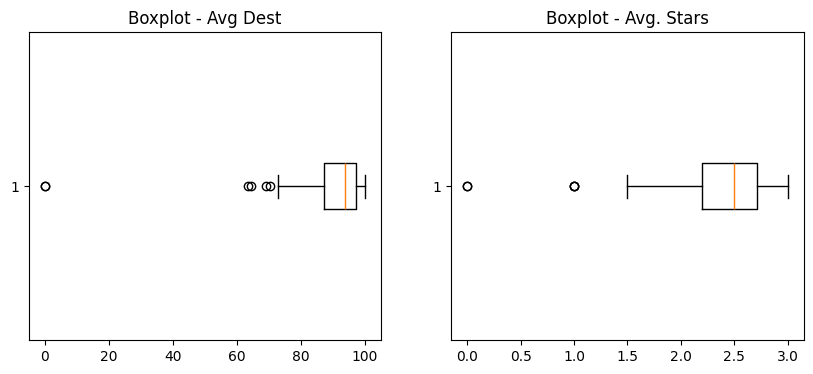

In [17]:


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df_clean["Avg Dest"], vert=False)
axes[0].set_title("Boxplot - Avg Dest")

axes[1].boxplot(df_clean["Avg. Stars"], vert=False)
axes[1].set_title("Boxplot - Avg. Stars")

plt.show()


In [18]:
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    return outliers, limite_inferior, limite_superior


In [19]:
outliers_dest, li_dest, ls_dest = detectar_outliers_iqr(df_clean["Avg Dest"])
outliers_stars, li_stars, ls_stars = detectar_outliers_iqr(df_clean["Avg. Stars"])

print(f"Outliers en Avg Dest: {len(outliers_dest)}")
print(f"Outliers en Avg. Stars: {len(outliers_stars)}")


Outliers en Avg Dest: 6
Outliers en Avg. Stars: 5


## Outliers: impacto potencial 
Analizaremos el posible impacto en el modelo de los outliers. El analisis fue hecho respecto de las dos variables mas importantes.

## Analisis de los outliers.
Podemos observar en avg dest , que despues de haber visto que tenemos 6 outliers en esta columna, 2 de ellos representand desconexion del juego con un 0 % en los ataques, y el resto son ataques que se salen de la media, en los cuales los jugadores han rendido por debajo
del nivel general del clan. 
En cuanto a avg stars, tenemos 5 outliers(Solo se aprecian dos porque este estilo de grafica agrupa varios valores iguales en un mismo redondito) que estan representados dos de ellos directamente relacionados con la desconexion de los jugadores con 0 estrellas, y los otros 3 por jugadores que tienen una media cercana a uno, lo que indica un rendimiento bajisimo para ellos.
Por utlimo en cuanto a eliminarlos de cara al modelo no sería correcto por que representan situaciones reales del juego y aun que puede reducir un poco la capacidad de prediccion general es mejor idea mantenerlos.


## 7. Visualización de datos
Las siguientes gráficas se han seleccionado por su relevancia para interpretar el rendimiento y el estilo de ataque en CWL.

## 7.1 Visualización general

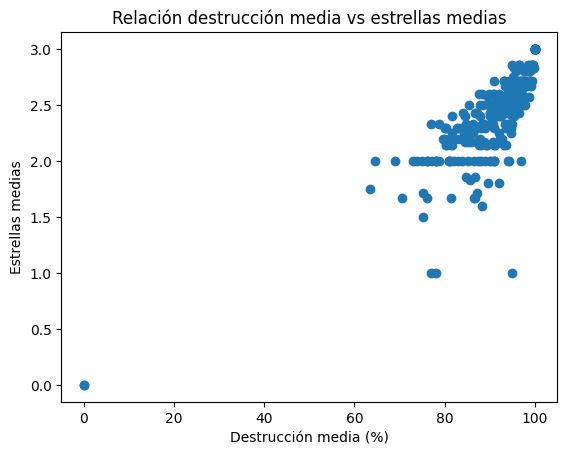

In [20]:

# Gráfico 1 : Destrucción media vs estrellas medias
plt.scatter(df_clean["Avg Dest"], df_clean["Avg. Stars"])
plt.xlabel("Destrucción media (%)")
plt.ylabel("Estrellas medias")
plt.title("Relación destrucción media vs estrellas medias")
plt.show()

En esta gráfica se aprecia una relación directa entre la destrucción media y las estrellas medias obtenidas. A mayor porcentaje de destrucción, generalmente se consiguen más estrellas, aunque no siempre una destrucción muy alta garantiza el máximo de estrellas, lo que indica que la ejecución del ataque también influye.

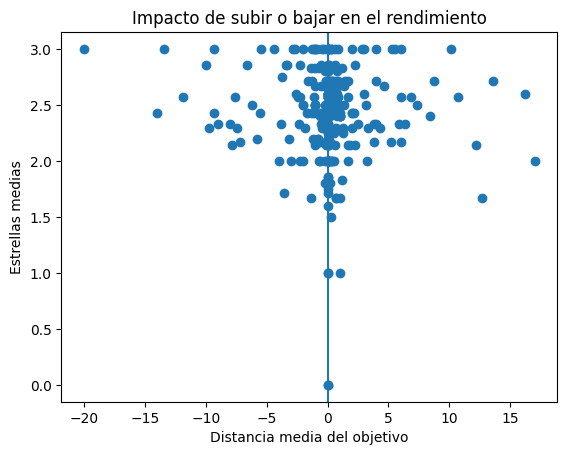

In [21]:

# Gráfico 2: Distancia media del objetivo vs estrellas medias
plt.scatter(df_clean["Avg. Target Distance"], df_clean["Avg. Stars"])
plt.axvline(0)
plt.xlabel("Distancia media del objetivo")
plt.ylabel("Estrellas medias")
plt.title("Impacto de subir o bajar en el rendimiento")
plt.show()

En esta grafica podemos observar que la mayoria de jugadores realizan ataque a su mismo objetivo , esto significa que la estrategia del clan suele ser de espejo lo que significa que le atacas al rival que ocupe la misma posicion que tu en el equipo contrario.
Observamos que hay mas cantidad de gente que baja a rivales mas asequibles de la que arriesga a rivales mas complicados aunque presentan ambos buenos resultados ya que las estrellas medias conseguidas en ambos casos estan en la media del clan.

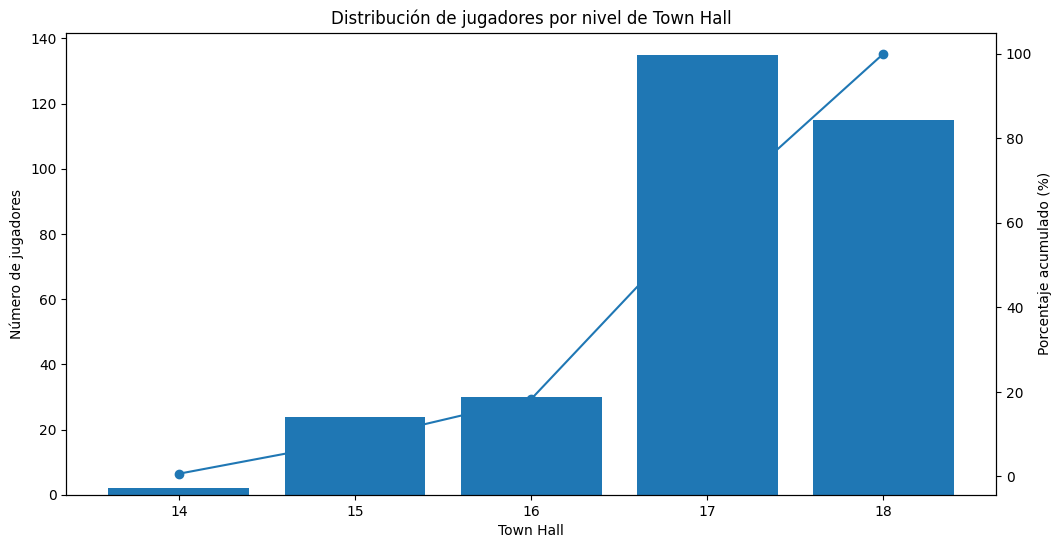

In [22]:


# Recuento por Town Hall
th_counts = df_clean["Town Hall"].value_counts().sort_index()

# Porcentaje acumulado
th_percent = th_counts.cumsum() / th_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12,6))

# Barras jugadores
ax1.bar(th_counts.index, th_counts.values)
ax1.set_xlabel("Town Hall")
ax1.set_ylabel("Número de jugadores")
ax1.set_title("Distribución de jugadores por nivel de Town Hall")

# Segunda escala → porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(th_counts.index, th_percent.values, marker="o")
ax2.set_ylabel("Porcentaje acumulado (%)")

plt.show()


Distribucion de los jugadores por ayuntamiento donde vemos claramente que se aglomeran los jugadores en los niveles mas altos de th.

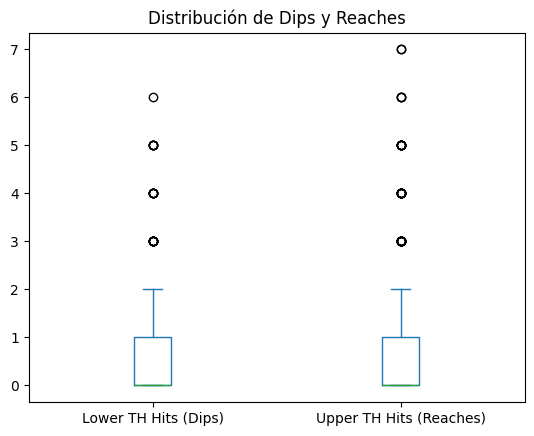

In [23]:

# Gráfico 3: Dips y Reaches (distribución)
df_clean[["Lower TH Hits (Dips)", "Upper TH Hits (Reaches)"]].plot(kind="box")
plt.title("Distribución de Dips y Reaches")
plt.show()

Este gráfico compara el uso medio de ataques a ayuntamientos inferiores (dips) y superiores (reaches) en cada mes. Permite identificar cambios de estrategia, observándose meses más conservadores y otros con mayor asunción de riesgo.

In [24]:
# Creamos esta serie para mostrar la media de estrellas por mes, ordenamos los meses para que se muestren en el orden correcto y poder mostrar todos los meses , ya que con una grafica normal se mostraba un mes si un mes no y no es la grafica que queriamos obtener.
orden_meses = ["Mayo","Junio","Julio","Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre", "Enero","Febrero"]
serie = (
    df_clean
    .groupby("cwl_month")["Avg. Stars"]
    .mean()
    .reindex(orden_meses)
)

print(serie)

cwl_month
Mayo          2.456111
Junio         2.468667
Julio         2.492258
Agosto        2.200000
Septiembre    2.346364
Octubre       2.368182
Noviembre     2.411053
Diciembre     2.706286
Enero         2.449130
Febrero       2.444571
Name: Avg. Stars, dtype: float64


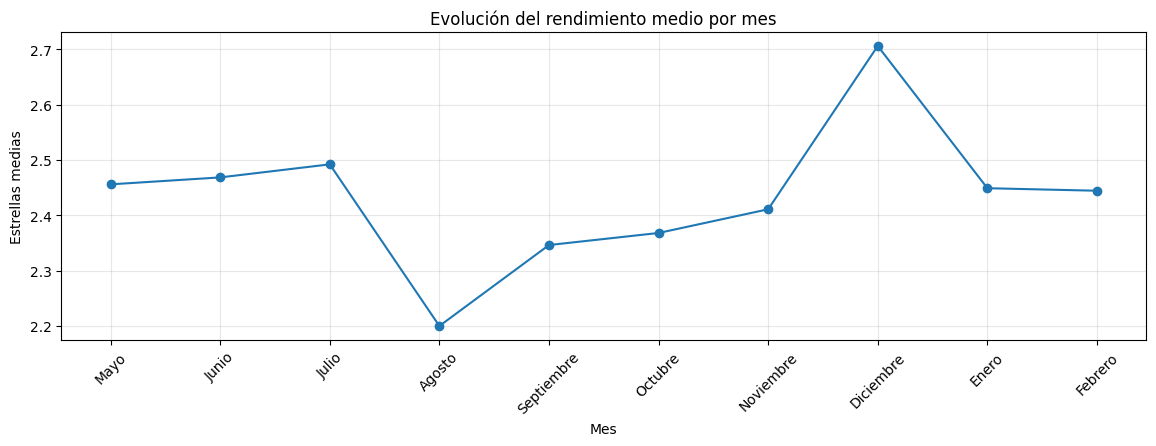

In [25]:
plt.figure(figsize=(14, 4))

plt.plot(serie.index, serie.values, marker="o")

plt.xticks(
    ticks=range(len(serie.index)),
    labels=serie.index,
    rotation=45
)

plt.xlabel("Mes")
plt.ylabel("Estrellas medias")
plt.title("Evolución del rendimiento medio por mes")
plt.grid(alpha=0.3)
plt.show()


Observamos en este grafico una regularidad ofensiva de los jugadores del clan que salvo en el mes de diciembre que hay un pico bastante alto de mejoria de la media , los demas meses es similar quitando agosto que estaria el mes con peor rendimiento de todos.


## 7.2 Visualización temporal de las ligas.

Analizaremos la evolucion de las estrellas del clan con un boxplot.

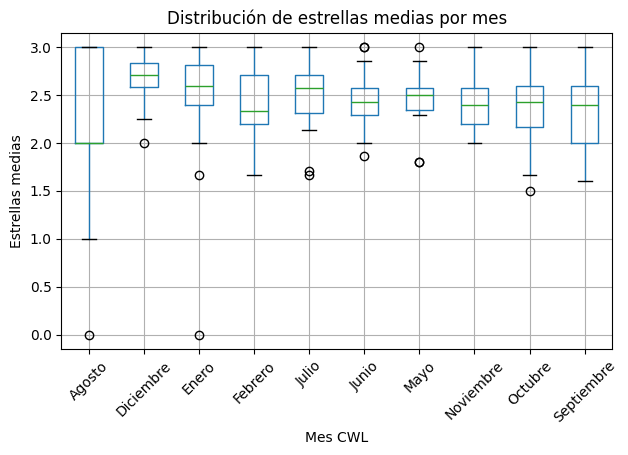

In [26]:

# Gráfico A: Distribución mensual de estrellas medias (boxplot)
df_clean.boxplot(column="Avg. Stars", by="cwl_month")

plt.title("Distribución de estrellas medias por mes")
plt.suptitle("")
plt.xlabel("Mes CWL")
plt.ylabel("Estrellas medias")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Podemos observar que la distribucion media de las estrellas se condensa en la mayoria de meses en torno a los 2,5. Podemos apreciar que algunos meses presentan mas dispersion en la media lo que nos da a entender que han podido haber o desconexiones o ataques fallidos con bajo resultado.

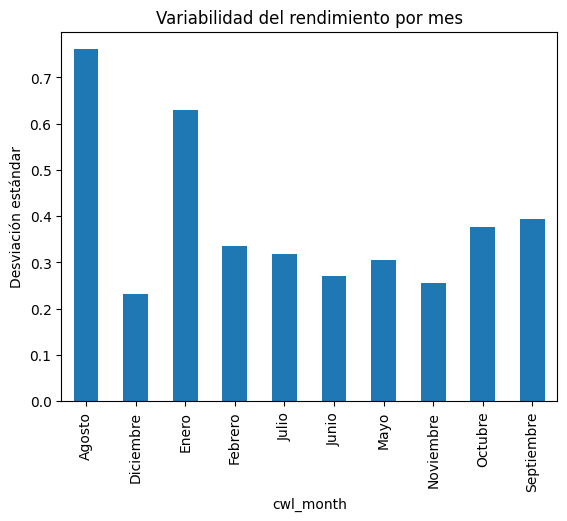

In [27]:

# Gráfico B: Variabilidad del rendimiento por mes (desviación estándar)
df_clean.groupby("cwl_month")["Avg. Stars"].std().plot(kind="bar")
plt.ylabel("Desviación estándar")
plt.title("Variabilidad del rendimiento por mes")
plt.show()

La desviación estándar de las estrellas medias muestra la variabilidad del rendimiento mensual. Meses con valores más altos indican mayor irregularidad entre jugadores, mientras que valores bajos reflejan un rendimiento más solido.

## 8. Calidad global del dataset y conclusion del mismo.

El analisis nos dice que tenemos una calidad de datos adecuada para el estudio, tenemos pocos valores nulos lo que nos permitira un buen analisis. Tenemos algunos outliers propios del rendimiento tipico dentro del juego, los cuales no eliminaremos al ser relevantes.
En cuanto a la calidad global del dataset creo que es bastante completo, despues de la reunion que tuvimos el ultimo dia decidimos que debiamos de aumentar la cantidad de registros que teniamos para que el analisis del proyecto pudiera ser mas potente y poder obtener mejores estadisticas ya que cuantos mas meses dispongas mejor puede ser el analisis posterior. Como podemos observar en la fotografica inferior no obtenemos datos del bot desde abril hacia abajo del año 2025 asique el analisis que hemos podido realizar ha sido solamente desde mayo de 2025 hasta febrero de 2026. Nos queda un dataset bastante completo con estadisticas generales del rendimiento del clan en distintos meses. No necesitaremos realizar una transformacion ni limpieza posterior ya que el dataset queda bastante completo.
Para mi gusto el dataset es bastante completo y nos permitira realizar distintos tipos modelados.

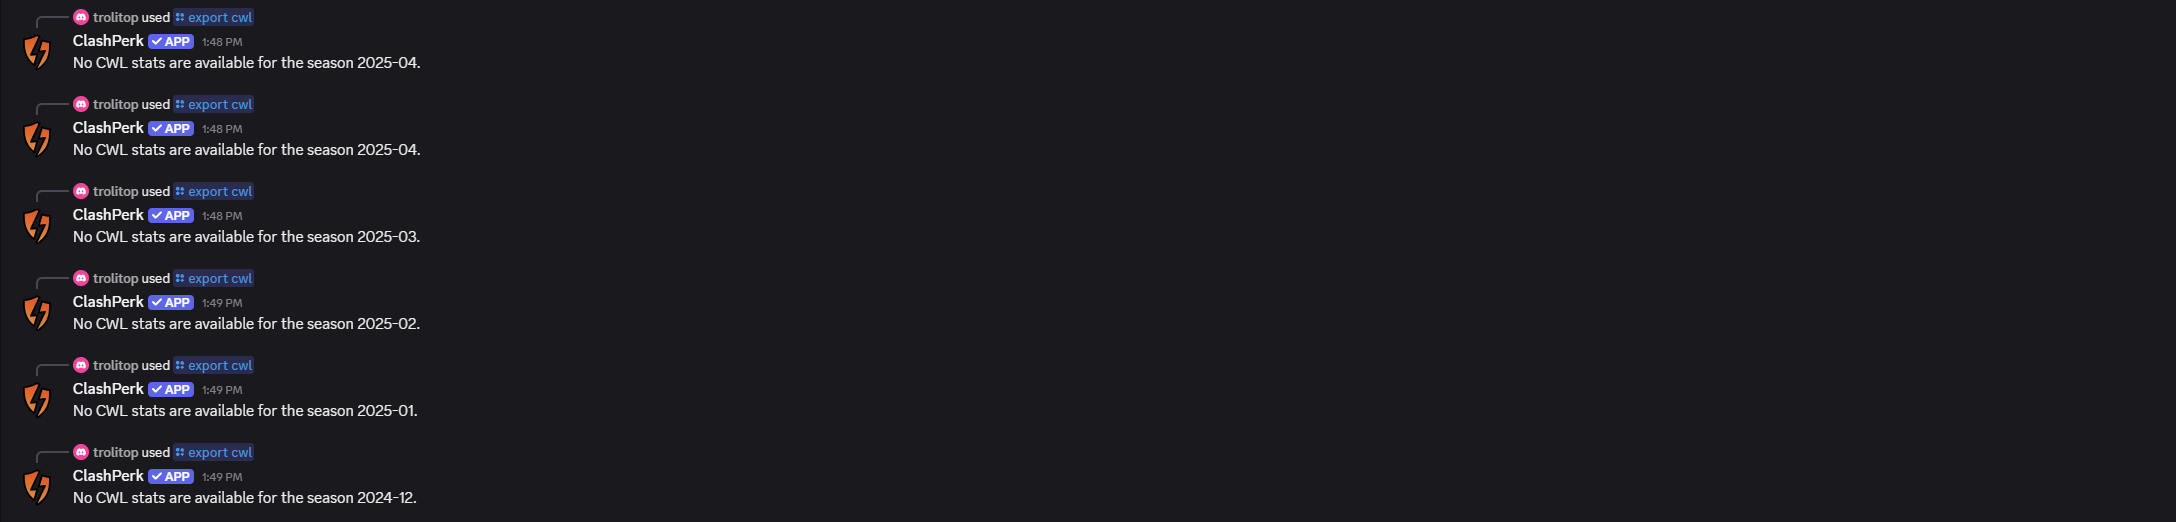

In [28]:
# Gracias a importar anteriormente la libreria de python inscrustamos la imagen del discord donde se ve que no se puede obtener mas registros de meses anteriores.
Image("clash.png")

## PARTE 2: Inferencia y Modelado (Dataset Propio)

## 1. Análisis de Correlación

En esta sección se analizan las relaciones con una matriz de correlación.

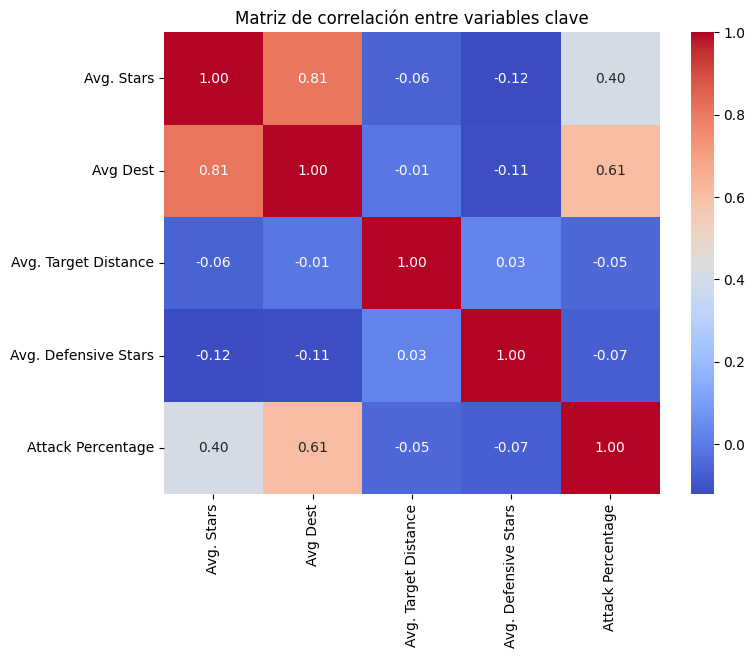

In [29]:
# Para esta matriz añadimos la columna de porcentaje de ataque ya que puede ser interesante ver su correlacion con las demas variables.
corr_vars = [
    "Avg. Stars",
    "Avg Dest",
    "Avg. Target Distance",
    "Avg. Defensive Stars",
    "Attack Percentage"
]

# Pintamos la matriz de correlacion con seaborn.
corr_matrix = df_clean[corr_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación entre variables clave")
plt.show()


# Analisis de la matriz de correlacion.
Aqui es donde empezamos a ver que quiza necesitamos otro tipo de datasets si quisieramos realizar una regresion lineal mas potente y que pudieramos valorar mas correlaciones dentro del dataset pero bueno igualmente los resultados son buenos, como es logico hay una correlacion positiva entre porcentaje de destruccion y media de estrellas.
En las demas, la correlacion apenas existira de manera ni negativa ni positiva salvo en el porcentaje de ataque y la media de destruccion. Obviamente tambien hay buena correlacion entre avg dest y attack percentaje , cuando hay un porcentaje alto de participacion la destruccion puede ser mas alta aunque esto es algo que se da mas en clanes de alto nivel ya que podria haber una participacion maxima y tener un porcentaje bajo de destruccion si tu nivel fuera malo.

# 2. Relaciones Bivariantes

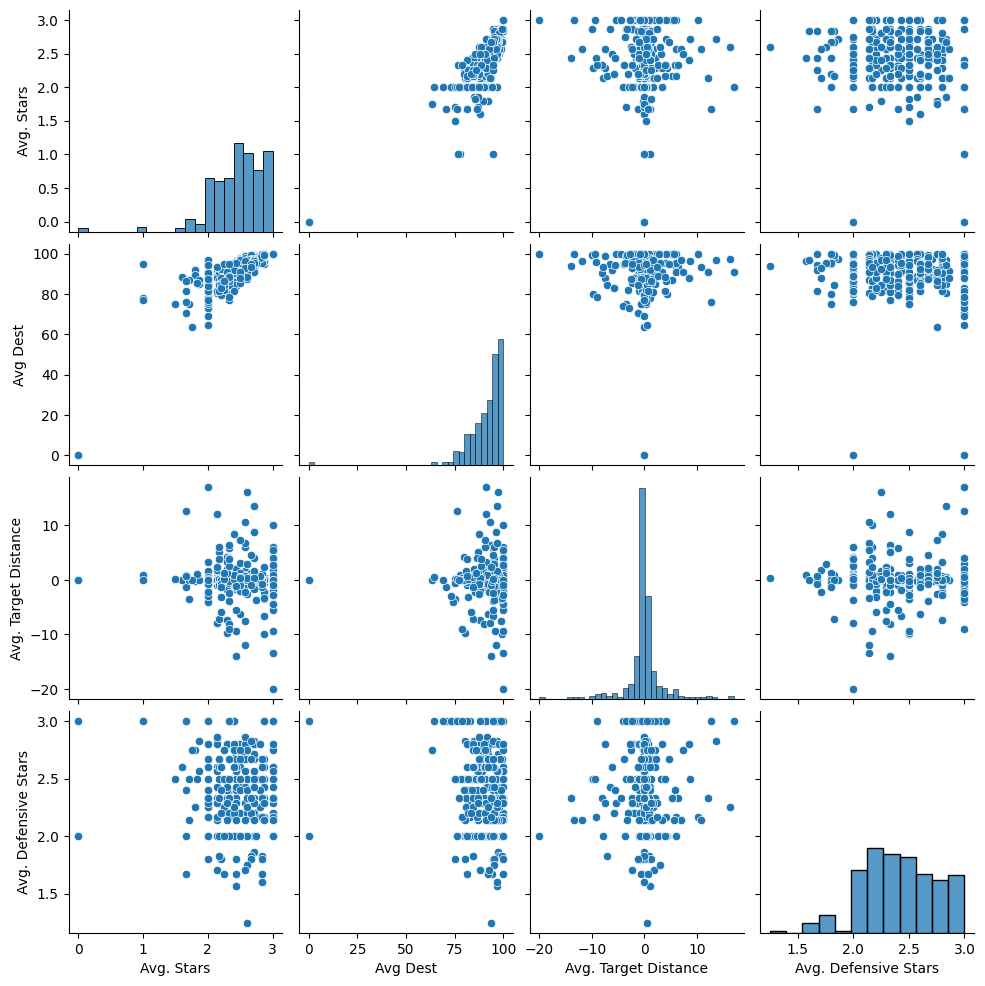

In [30]:

# En este pairplot he querido añadir las variables que pienso que son mas interesantes de cara a un analisis posterior.
# Media de estrellas, media de destinos, media de distancia al objetivo y media de estrellas defensivas.
vars_pairplot = [
    "Avg. Stars",
    "Avg Dest",
    "Avg. Target Distance",
    "Avg. Defensive Stars"
]

sns.pairplot(df_clean[vars_pairplot])
plt.show()

En este pairplot podemos ver la relación las vasriables mas importantes del rendimiento ofensivo y defensivo de los jugadores. Tenemos en diagonal los histogramas que nos permiten ver cómo se distribuyen los valores de cada variable, mientras que fuera de la diagonal se muestran los scatter que nos permiten analizar relaciones entre columnas.

Se puede ver claramente que Avg Dest y Avg. Stars presentan una relación positiva bastante marcada, ya que cuando aumenta el porcentaje medio de destrucción, también suelen aumentar las estrellas medias obtenidas en los ataques. Esto tiene bastante sentido dentro del juego, porque conseguir más destrucción normalmente implica mejores resultados en estrellas.

Pero cuando analizamos Avg. Target Distance, se observa que la mayoría de valores están muy concentrados alrededor de 0 y no se aprecia una relación clara con el resto de variables. Esto nos deja ver que subir o bajar de objetivo no cambia el rendimiento de los jugadores.

En el caso de Avg. Defensive Stars, la distribución aparece bastante centrada entre valores medios y tampoco muestra una relación fuerte con las variables ofensivas, lo que puede indicar que el rendimiento defensivo depende de otros factores diferentes al ataque como pueda ser la base que tengas en defensa, la habilidad del rival a la hora de atacarte etc.

En general, este grafico lo que nos ayuda es a confirmar que la variable más relacionada con el rendimiento ofensivo es la destrucción media, mientras que otras variables como la distancia del objetivo o las estrellas defensivas parecen tener un impacto menor o más disperso.

## 3. Regresión Lineal (Scikit-Learn):

In [31]:


# Variables predictoras y objetivo
X = df_clean[["Avg Dest", "Avg. Target Distance"]]
y = df_clean["Avg. Stars"]

# Train / Test Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenamiento del modelo
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Predicciones
y_pred = lin_model.predict(X_test)

# Evaluación
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Regresión Lineal")
print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")


Regresión Lineal
R²: 0.629
RMSE: 0.218


Estos datos nos indican una variabilidad de las estrellas del 62% lo que es normal por que el rendimiento depende directamente de factores que no se han medido, como la habilidad del jugador, estrategia realizada y demas. En el caso del rmse el modelo estaria enseñandonos que se equivoca en 0.21 estrellas aproximadamente. 

Vamos a calcular los residuos del modelo, que en nuestro caso seria la diferencia entre el valor deal de las estrellas medias y el valor que predice el modelo.

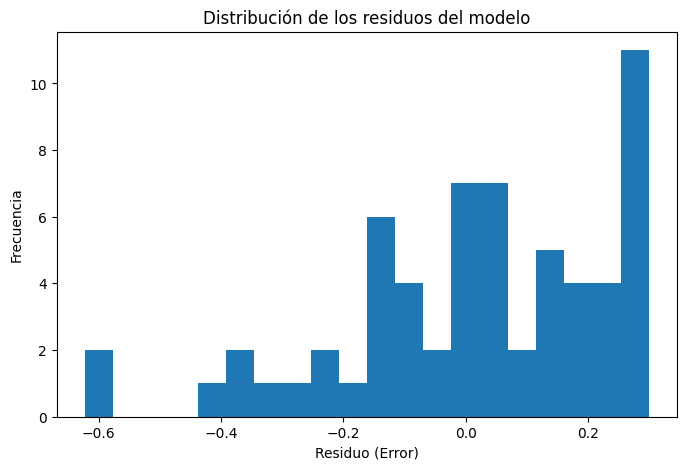

In [32]:
# Calculamos residuos
residuos = y_test - y_pred

plt.figure(figsize=(8,5))
plt.hist(residuos, bins=20)
plt.title("Distribución de los residuos del modelo")
plt.xlabel("Residuo (Error)")
plt.ylabel("Frecuencia")
plt.show()

Podemos observar que los errores se concentran alrededor de 0, lo que nos da a entender que el modelo no tiene un sesgo claro hacia como estimar los resultados. La distribucion no es completamente simetrica y se observan valores mas alejados lo que indica que hay casos en los que el modelo comete errores mas grandes. 

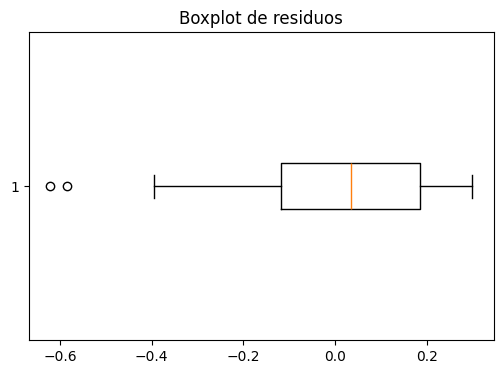

In [33]:
# Boxplot de residuos
plt.figure(figsize=(6,4))
plt.boxplot(residuos, vert=False)
plt.title("Boxplot de residuos")
plt.show()

En el boxplot se confirma lo que hemos visto en el histograma ya que aparecen outliers negativos que representan donde el modelo ha predicho mas estrellas de las que se obtienen realmente.

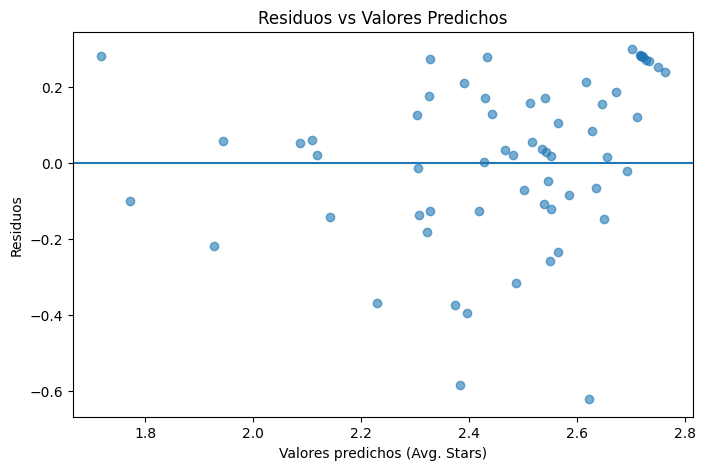

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuos, alpha=0.6)

plt.axhline(0)  # Línea horizontal en error 0

plt.title("Residuos vs Valores Predichos")
plt.xlabel("Valores predichos (Avg. Stars)")
plt.ylabel("Residuos")
plt.show()

Apreciamos dispersion en distintos rangos de prediccion, lo que nos puede hacer ver que el modelo no explica la que varie el rendimiento. Para mi manera de pensar, es algo que es completamente logico ya que este dataset no registra factores externos como la habilidad del jugador o la estrategia que se utilice tanto en ataque como en defensa. Si tuvieramos mas variables que aportaran mas calidad al dataset podriamos tener unos mejores resultados pero son bastante buenos para lo que tenemos.

Respecto a la parte del cumplimiento de los supuestos , creo que puede estar bastante cerca de cumplirlos ya que los residuos se distribuyen alrededor del cero y no hay patrones claros. Lo cierta dispersion da que pensar acerca de lo que comente anteriormente que seguramente podriamos obtener un mejor modelo si tuvieramos mas variables que aumentaran la capacidad de ser analizado de una manera mejor.

## 4. Regresión Logistica (Scikit-Learn):

## Explicacion de la regresión logistica en relacion a nuestra variable objetivo y nuestro dataset.

Las regresiones logisticas , a diferencia de las lineales estan hechas para predecir probabilidades o categorias. En nuestro caso la lineal predice estrellas medias, la logistica esta hecha para un modelo de clasificacion.
Los ejemplos que se me ocurren rapidamente para este dataset para poder hacer una regresion logistica sería buen ataque mal ataque(dependiendo de cuantas estrellas tenga), ataque existoso o fallido(1 o 0 estrellas fallido, 2 o 3 existoso) y conseguir tres estrellas o no hacerlo.

En mi caso vamos a hacer que todos los ataques con 2.5 de media esten calificados como buenos ataques y los demas seran malos.

In [35]:
## Creamos la variable objetivo para este modelo, que sera buen ataque , para los ataques superiores a 2.5.
df_clean["Buen_Ataque"] = (df_clean["Avg. Stars"] >= 2.5).astype(int)

In [36]:
# Hacemos la regresion logistica para predecir si el ataque sera bueno utilizando la destruccion y la distancia al objetivo. Dividimos los datos en 80/20 para entrenamiento y testeo.
X = df_clean[["Avg Dest", "Avg. Target Distance"]]
y = df_clean["Buen_Ataque"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
# Hacemos las predicciones con el modelo de regresion logistica.
y_pred = log_model.predict(X_test)

Esta sera la unica celda en la que importe librerias ya que el resto de librerias las importamos siempre en la primera celda por que es lo logico y como hay que hacerlo por buenas practicas. La explicacion de que esto sea asi es debido a que en el ejercicio en un principio se solicito que estudiaramos las metricas r2 y rmse para una regresion logistica, lo que investigando un poco nos ha llevado a decidir que las metricas que se utilizan en la regresion logistica son distintas de la lineal.

In [38]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report: ")
print(classification_report(y_test, y_pred))
print("Matriz de confusion: ")
print(confusion_matrix(y_test, y_pred))
print("R² Score:", r2)
print("RMSE:", rmse)

Accuracy: 0.7580645161290323
Classification report: 
              precision    recall  f1-score   support

           0       0.70      0.73      0.72        26
           1       0.80      0.78      0.79        36

    accuracy                           0.76        62
   macro avg       0.75      0.75      0.75        62
weighted avg       0.76      0.76      0.76        62

Matriz de confusion: 
[[19  7]
 [ 8 28]]
R² Score: 0.0064102564102564985
RMSE: 0.4918693768379647


## ANALISIS DE LA REGRESION LOGISTICA

La clase 0 seran los ataques malos y la clase 1 los buenos ataques. Esto nos dara indicaciones perfectas de como ha rendido el modelo.
Tenemos una precision del 76%, esto nos indica una clasificacion correcta de 3 de cada 4 ataques. Un resultado bastante bueno para los datos que tenemos con sus limitaciones ya comentadas anteriormente. 
En preccision y recall tenemos unos resultados parecidos, obteniendo ligeramente mejores resultado a la hora de detectar si una ataque es existoso
En cuanto a la matriz de confusion , tenemos unos resultados parecidos lo que nos da a entender que no tenemos sesgo hacia ninguna de las clases, porque el nnumero de error es practicamente igual en las dos categorias.
Finalmente observamos que los valores de r2 y rmse no ofrecen unos resultados interpretables ya que no son metricas que esten hechas para este tipo de regresion logistica.

## Regresión logística: adecuación del modelo

Esta parte ya ha sido comentada a lo largo del desarrollo de la regresion logistica, pero haremos un pequeño resumen del por que la regresion logistica no esta hecha para este dataset inicialmente.
Nuestra variable inicialmente en la regresion lineal fue avg stars , la cual es continua, este tipo de variable esta hecha mas para regresiones lineales, lo que nos llevo a crear una variable binaria que hace que el problema sea de clasificacion.
La regresion logistica lo que hace principalmente es predecir una probabilidad y luego se convierte a 0 o 1 . Obviamente no predice las estrellas pero si que va a predecir la probabilidad de exito que es por lo que hemos podido hacer una regresion logistica adecuada.
Obviamente los dos modelos te permiten hacer un analisis que lleva a un punto parecido, en uno se analiza rendimiento en estrellas y el otro te clasifica los ataques en funcion de la probabilidad de exito. 


## Comparación de modelos

En cuanto a la comparación de modelos es posible que ya con los comentarios de ambas regresiones puede quedar explicado cual es mas interesante para nuestros datos, pero hay que recalcar que para nuestros datos la regresion lineal es mas adecuada ya que el objetivo principal es predecir el numero medio de estrellas, variable la cual es continua. Las variables como distancia al objetivo y destruccion media son las que valoramos cuanto pueden influir en el rendimiento .
Y en el caso de la regresion logistica lo que hacemos es simplificar las cosas a ataque exitoso o malo. Podría ser util pero no tienes informacion exacta acerca de las estrellas obtenidas lo que no es interesante para nuestro analisis. 

## 5. Conclusion 

La conclusion final de la parte de regresion sería que nuestros dos modelos responden bien ante los datos que tenemos , obteniendo porcentajes altos en ambas regresiones y con un buen rendimiento. Podríamos cerrar esta parte con que los analisis mas reveladores son los que nos ha mostrado la regresion lineal con un porcentaje bastante alto del 62% a pesar de que quiza obtendriamos mejores resultados si tuvieramos otras variables mas potentes que avg dest y avg distance para realizar las regresiones, igualmente los resultados obtenidos son satisfactorios.

## PARTE 3: Regresión Lineal "From Scratch" (Datos Simulados)

##  1. Regresión Lineal "From Scratch" (Datos Simulados)

Buscamos en esta parte entender todo el codigo que hay detras de hacer la regresion lineal sin utilizar librerias de python, llevando las matematicas al codigo.


Intercepto estimado: 4.1046983135241195
Pendiente estimada: 2.865830228239851


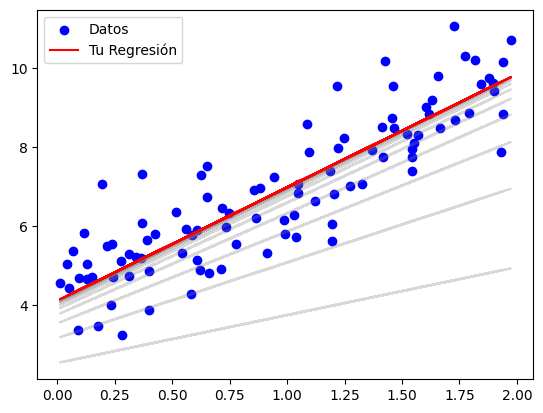

In [39]:

# --- NO TOCAR: GENERACIÓN DE DATOS ---
np.random.seed(42)
X_mock = 2 * np.random.rand(100, 1)
y_mock = 4 + 3 * X_mock + np.random.randn(100, 1)
# -----------------------------------

def evolve_linear_regression( X, y, iteraciones=16, eta=0.1):
    """
    Calcula la pendiente (w) y el intercepto (beta_0)
    usando las fórmulas de OLS con NumPy.
    Returns: (b, w)
    """
    # TU CÓDIGO AQUÍ
    n=len(X)
    #Generacion aleatoria de parametros (numpy)
    w = np.random.randn()
    b = np.random.randn()

    for i in range(1, iteraciones):
        # calcular el error

        y_pred = b + w * X
        error = y - y_pred

        #Ajustar parametros
        dw = (-2 / n) * np.sum(X * error)
        db = (-2 / n) * np.sum(error)

        w = w - eta * dw
        b = b - eta * db


        #pintar recta

        pintar_recta(b, w, X, y)

    return b, w


def pintar_recta(b, w, X, y):
    plt.plot(X, b + w * X_mock, color='gray',alpha=0.3)


# Probemos tu función
b, w = evolve_linear_regression(X_mock, y_mock)
print(f"Intercepto estimado: {b}")
print(f"Pendiente estimada: {w}")

# Verificación visual
plt.scatter(X_mock, y_mock, color='blue', label='Datos')
plt.plot(X_mock, b + w * X_mock, color='red', label='Tu Regresión')
plt.legend()
plt.show()



Los resultados de intercepto y de pendiente son bastante cercanos a los que habiamos puesto en los datos generados: y_mock = 4 + 3 * X_mock + np.random.randn(100, 1), en esta formula lo que nos lleva a pensar que el descenso del gradiente se ha hecho de manera correcta, la tasa de aprendizaje : def evolve_linear_regression( X, y, iteraciones=16, eta=0.1): añadida en esta formula y las iteraciones en la misma son las adecuadas para poder obtener los resultados que queriamos. 
En la grafica podemos ver que los puntos azules representan los datos simulados con ruido, la linea roja es el modelo aprendido y las grises muestran el ajuste de la recta iteracion tras iteracion.

En un principio habiamos utilizado las iteraciones para pintar la evolucion de la recta hacia su posicion pero despues de revisar las clases , el compañero David, nos enseño una forma de pintar la evolucion de la recta en una sola grafica, con lo que podemos observar su evolucion de una manera progresiva haciendose notar que en las ultimas rectas ya la correccion de la recta es minima ya que esta cerca de llegar a la recta principal, por lo que podemos ver mas cantidad de rectas en un espacio mas reducido hasta que se ajusta la recta finalmente.

## Prediccion manual utilizando las formulas matematicas aplicadas al codigo de python.

In [40]:
## Para la prediccion manual del mse y el r2 vamnos a utilizar sus formulas matematicas para calcularlo a mano, la formula matematica del mse es la siguiente: mse = (1/n) * sum((y_true - y_pred)^2) y la formula del r2 es la siguiente: r2 = 1 - (sum((y_true - y_pred)^2) / sum((y_true - mean(y_true))^2))
## Utilizaremos :.3f para redondear los resultados a tres decimales y que sea mas legible.
y_pred_manual = b + w * X_mock
n = len(y_mock)
mse_manual= (1/n) * np.sum((y_mock - y_pred_manual)**2)
print(f"MSE manual: {mse_manual:.3f}")

ss_res= np.sum((y_mock - y_pred_manual)**2)
sstot= np.sum((y_mock - np.mean(y_mock))**2)
r2_manual = 1 - (ss_res / sstot)
print(f"R² manual: {r2_manual:.3f}")

MSE manual: 0.810
R² manual: 0.768


## 2. Comparación con Scikit-Learn

In [42]:

# Entrenamos modelo de Scikit-Learn
modeloSl = LinearRegression()
# Utilizamos los mismos datos simulados para entrenar el modelo de sklearn y poder comparar los resultados con el modelo manual.
modeloSl.fit(X_mock, y_mock)

# Parámetros obtenidos
b_sl = modeloSl.intercept_[0]
w_sl = modeloSl.coef_[0][0]

print("Comparación de coeficientes:")
print(f"Resultado del Intercepto en manual: {b:.3f}, y de la Pendiente: {w:.3f}")
print(f"Resultado del intercepto con sklearn: {b_sl:.3f}, y de la Pendiente: {w_sl:.3f}")

# Predicciones
y_pred_sl = modeloSl.predict(X_mock)

# Métricas
mse_sk = mean_squared_error(y_mock, y_pred_sl)
r2_sk = r2_score(y_mock, y_pred_sl)

print("Comparación de métricas:")
print(f"Resultado de la mse manual: {mse_manual:.3f}")
print(f"Resultado de la mse sklearn: {mse_sk:.3f}")

print(f"Resultado del r2 manual: {r2_manual:.3f}")
print(f"Resultado del r2 de sklearn: {r2_sk:.3f}")


Comparación de coeficientes:
Resultado del Intercepto en manual: 4.105, y de la Pendiente: 2.866
Resultado del intercepto con sklearn: 4.215, y de la Pendiente: 2.770
Comparación de métricas:
Resultado de la mse manual: 0.810
Resultado de la mse sklearn: 0.807
Resultado del r2 manual: 0.768
Resultado del r2 de sklearn: 0.769


## Valoracion de las metricas y los coeficientes de los modelos manual y sklearn

Los resultados obtenidos nos dicen que hemos realizado correctamente la regresion lineal aplicando las formulas y utilizando la libreria de sklearn. La diferencia en los resultados es minima y por lo que hemos podido entender en las clases se debe al descenso del gradiente que se realiza en la manera manual. Revisando la documentacion de la libreria sklearn en la pagina oficial: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html podemos observar en el primer parrafo que se utiliza una solucion analitica de los minimos cuadrados ordinarios. Scikit-learn utiliza exactamente ordinary least squares para la regresion lineal y no el descenso de gradiente. La diferencia entre una y otra seria que el descenso de gradiente busca el minimo de paso en paso y depende de la tasa de aprendizaje , en cambio, en sk-learn se calcula el minimo directamente y podria ser mas costoso si hubiera muchas variables. Los resultados obtenidos en el manual se podrian acercar mas a la regresion lineal de sklearn si aumentaramos el numero de iteracciones.

## (Ejercicio Extra) Adaptacion de la recta de regresión lineal a nuestro proyecto de clash.

In [43]:

# Selección de variables del dataset de Clash, convertimos el vector en formato columna con el reshape para que sea compatible con la función de regresion lineal.
X = df_clean["Avg Dest"].values.reshape(-1, 1)
y = df_clean["Avg. Stars"].values.reshape(-1, 1)
np.random.seed(42)
# En este caso utilizamos un eta 0.0001 por que los datos reales tienen valores grandes que rondan a 90 y con un eta mas grande el modelo no puede converger.
def evolve_linear_regression(X, y, iteraciones=100, eta=0.0001):
    """
    Implementación de regresión lineal simple usando NumPy
    mediante descenso de gradiente.
    """

    # Inicialización aleatoria de parámetros , basicamente porque el descenso del gradiente necesita un punto de partida y el random es la forma mas comun de hacerlo.
    w = np.random.randn()
    b = np.random.randn()
    
    #Numero de observaciones
    n = len(X)

    for i in range(iteraciones):
        # Predicción del modelo, utilizando la formula de la recta y = b + w * x, donde b es el intercepto y w es la pendiente.
        y_pred = b + w * X

        # Error (diferencia entre predicción y valor real)
        error = y_pred - y

        # Aqui es donde se calculan las derivadas parciales respecto a w y b.
        dw = (2 / n) * np.sum(error * X)
        db = (2 / n) * np.sum(error)

        # Actualización de parámetros, esto es parte del descenso del gradiente y utilizando el eta para controlar la velocidad de aprendizaje.
        w = w - eta * dw
        b = b - eta * db

    return b, w


# Entrenamos el modelo
b0, b1 = evolve_linear_regression(X, y)

print(f"Intercepto (b): {b0}")
print(f"Pendiente (w): {b1}")


Intercepto (b): -0.14344826998159266
Pendiente (w): 0.028364675371836862


La pendiente indica cuánto cambian las estrellas medias cuando aumenta en una unidad la destrucción media lo que nos dice que por cada 1% adicional de destrucción media, las estrellas aumentan aproximadamente 0.036.
En el caso del intercepto nos sale un valor negativo lo que no nos va a dar una interpretacion real, ya que el 0% de destruccion es una situacion poco habitual en el dataset. El resultado tan negativo es el valor de las estrellas cuando la destruccion media es 0 cosa que es practicamente nunca.

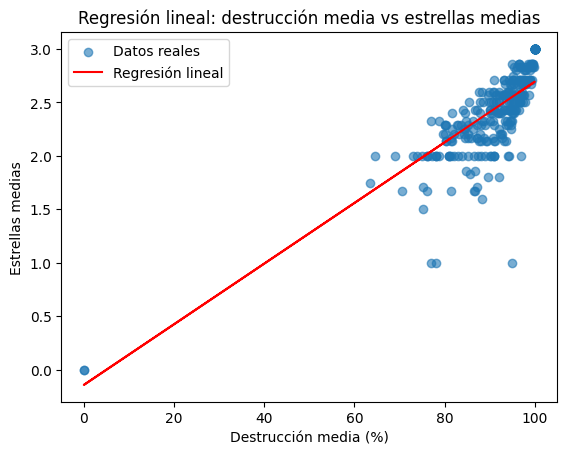

In [45]:
# Visualización de la regresión lineal
plt.scatter(X, y, alpha=0.6, label="Datos reales")
plt.plot(X, b0 + b1 * X, color="red", label="Regresión lineal")
plt.xlabel("Destrucción media (%)")
plt.ylabel("Estrellas medias")
plt.title("Regresión lineal: destrucción media vs estrellas medias")
plt.legend()
plt.show()

En esta regresión lineal simple se analiza cómo influye la destrucción media en las estrellas medias obtenidas. Se observa que existe una relación positiva entre ambas variables, de modo que un mayor porcentaje de destrucción suele traducirse en un mejor rendimiento ofensivo.

## PARTE 4: Series Temporales (Datos Simulados)

## Explicacion del ejercicio y como se ha generado la serie temporal.

En la siguiente linea de codigo: values = np.linspace(10, 50, len(dates)) + 10 * np.sin(np.linspace(0, 3.14*8, len(dates))) + np.random.normal(0, 2, len(dates)), es donde se genera la serie temporal dividida en tres apartados bien definidos, np linspace 
que distribuye la tendencia lineal ascendente desde 10 a 50 durante los 730 dias, con un promedio resultante en el ejercicio 30.01 que puede variar dependiendo de la ejecucion de la celda pero siempre sera un valor alrededor de 30.
La estacionalidad la tenemos en 10 * np.sin(np.linspace(0, 3.14*8, len(dates))), que el desglose de esta linea seria: un patron que se repite cada 6 meses que lo deducimos a raiz de 3.14*8 =25.12 que serian radiantes generando 4 ciclos completos que son 182 dias lo cual hemos utilizado luego en el period, de la descomposicion y simulamos las fluctuaciones de las estaciones. El rango de estacionalidad resultante del ejercicio esta alrededor de [-12.59,11.25].
En el ruido utilizamos una distribucion normal, el 0 representa que no tendremos sesgo sistematico y el 2 la desviacion estandar teorica. La simulacion que se hace es de cosas que no son predecibles como podrian ser fluctuaciones diarias del mercado, eventos aleatorios etc. EL resultado del ejercicio nos da un ruido que dependiendo de la ejecucion de la celda esta alrededor de 1.70


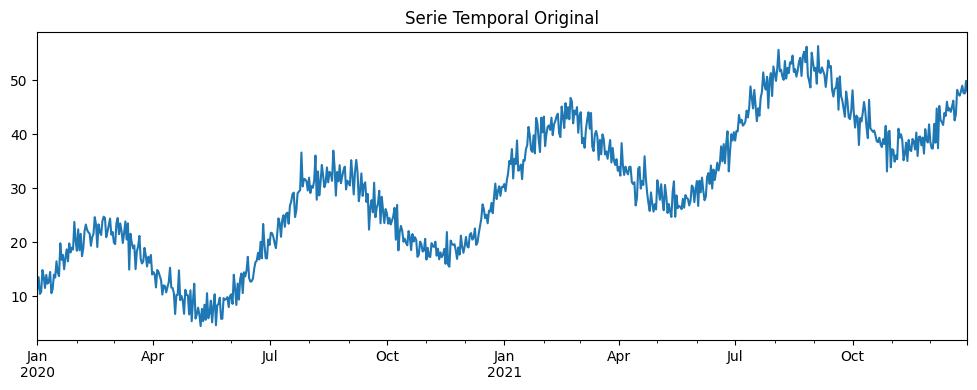

Ventas mensuales (promedio):
2020-01-31    15.225827
2020-02-29    21.674901
2020-03-31    19.247277
2020-04-30    11.278374
2020-05-31     7.676719
2020-06-30    14.664745
2020-07-31    25.794651
2020-08-31    31.872554
2020-09-30    28.741000
2020-10-31    21.260378
Freq: ME, Name: Sales, dtype: float64

Shape: (24,)


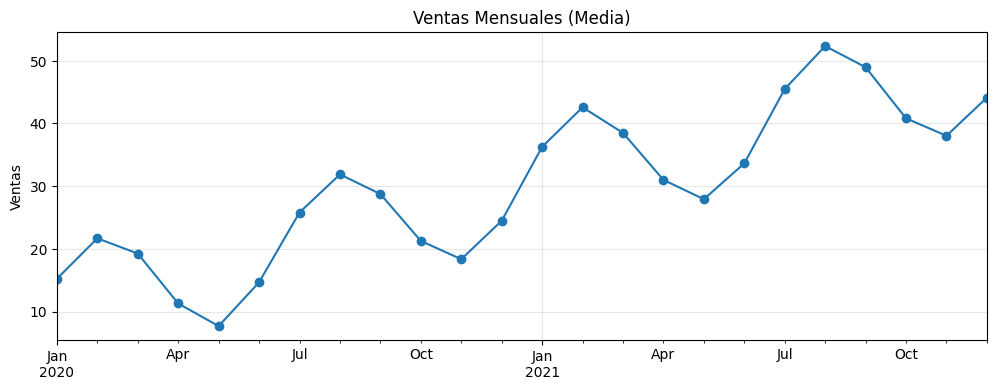

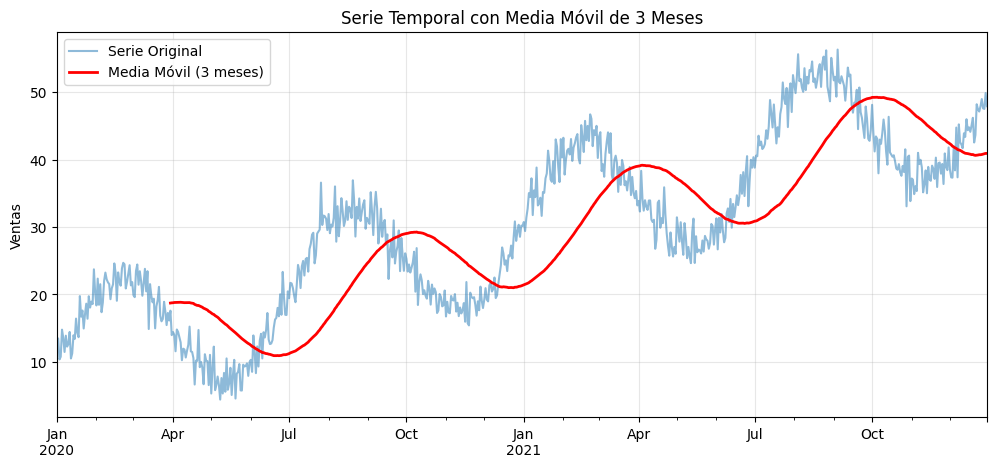

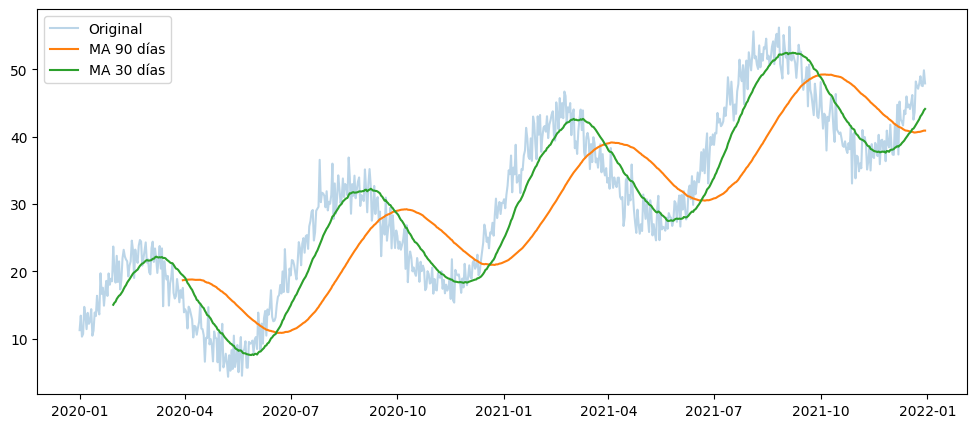

Descomposicion de la serie temporal:


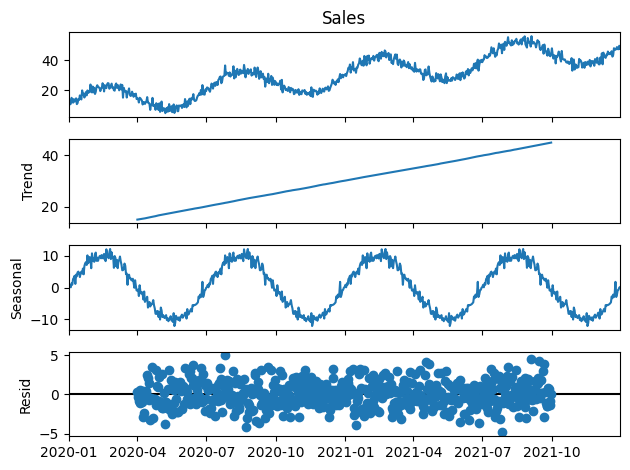

Análisis de Componentes
Tendencia promedio: 30.01
Estacionalidad - Rango: [-12.09, 12.13]
Ruido - Desviación estándar: 1.65


In [46]:

# --- NO TOCAR: GENERACIÓN DE DATOS TEMPORALES ---
# Aqui en el dates lo que hacemos es generar un rango de fechas desde el 1 de enero de 2020 durante dos años con una frecuencia diaria.
dates = pd.date_range(start='2020-01-01', periods=365*2, freq='D')

values = np.linspace(10, 50, len(dates)) + 10 * np.sin(np.linspace(0, 3.14*8, len(dates))) + np.random.normal(0, 2, len(dates))
# Aqui creamos el dataframe con las fechas como indice y los valores como columnas de ventas.
ts_df = pd.DataFrame({'Sales': values}, index=dates)
# -----------------------------------------------

# TU CÓDIGO AQUÍ

# 1. Plot inicial, que nos viene ya dado en el ejercicio para visualizar la serie tempooral original.
ts_df['Sales'].plot(title='Serie Temporal Original', figsize=(12,4))
plt.show()

# 2. Resampleo Mensual, el ejercicio te dice que debemos utilizar 'M' pero actualmente no se puede utilizar para offsets personalizados, por lo que utilizamos 'ME' que sirve para obtener el ultimo dia de cada mes, lo que nos da un resultado mas preciso.
# Tambien se puede utilizar 'MS' que nos da el primer dia de cada mes.
# Aqui agrupamos los datos diarios por mes y calculamos la media de ventas , que nos daría la tendencia mensual de las ventas.
monthly_sales = ts_df['Sales'].resample('ME').mean()
print("Ventas mensuales (promedio):")
print(monthly_sales.head(10))
print(f"\nShape: {monthly_sales.shape}")

# Visualizar resampleo mensual
monthly_sales.plot(title='Ventas Mensuales (Media)', figsize=(12,4), marker='o')
plt.ylabel('Ventas')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Media Móvil, con esto agrupamos los datos diarios en una ventana de 90 dias lo que puede ayudarnos para poder visualizar mejor una tendencia mas a medio plazo.
ts_df['Moving_Avg'] = ts_df['Sales'].rolling(window=90).mean()  
# Creamos otra media movil para la comparativa con una ventana de 30 dias para poder compararla con la de 90 dias y ver los resultados de cada una de ellas.
ts_df['Moving_Avg_30'] = ts_df['Sales'].rolling(window=30).mean()

# Visualizar serie original vs media móvil
plt.figure(figsize=(12,5))
ts_df['Sales'].plot(label='Serie Original', alpha=0.5)
ts_df['Moving_Avg'].plot(label='Media Móvil (3 meses)', color='red', linewidth=2)
plt.title('Serie Temporal con Media Móvil de 3 Meses')
plt.legend()
plt.ylabel('Ventas')
plt.grid(True, alpha=0.3)
plt.show()
# Visualizamos la media movil de 30 dias para compararla con la de 90 dias y ver los resultados de cada una de ellas.
plt.figure(figsize=(12,5))
plt.plot(ts_df['Sales'], alpha=0.3, label="Original")
plt.plot(ts_df['Moving_Avg'], label="MA 90 días")
plt.plot(ts_df['Moving_Avg_30'], label="MA 30 días")
plt.legend()
plt.show()

# 4. Descomposición mediante la funcion seasonal_decompose de la libreria statsmodels, con esta funcion lo que hacemos es descomponer la serie temporal en sus componentes de tendencia estacionalidad y ruido.
# Hemos decidido utilizar 182 como periodo porque en la grafica original se observan periodos de aproximadamente lo que puede indicar una estacionalidad semestral y darnos mejores resultados. 
print("Descomposicion de la serie temporal:")
result = seasonal_decompose(ts_df['Sales'], model='additive', period=182)
result.plot()
plt.tight_layout()
plt.show()

# Información adicional sobre los componentes
print("Análisis de Componentes")
print(f"Tendencia promedio: {result.trend.mean():.2f}")
print(f"Estacionalidad - Rango: [{result.seasonal.min():.2f}, {result.seasonal.max():.2f}]")
print(f"Ruido - Desviación estándar: {result.resid.std():.2f}")

## Analisis de las graficas de las medias moviles.
Al comparar las dos medias móviles podemos observar algunas diferencias bien claras.

La media verde que es la de 30 dias esta mas cerca de la serie original. Captura lo que nos puede dar a enternder que se vean mejor los cambios rapidos lo que nos dice que es mas sensible a variaciones a corto plazo.

En cambio, la media móvil naranja elimina practicamente el ruido y se muestra de una forma mas clara la tendencia general de la serie. Tiende a verse los cambios mucho mas lento por consecuencia.

En conclusion con la media de menos dias se captan mejor los cambios rapidos y la ventana de 90 dias se aproxima mas a la tendencia general. El tamaño de la ventana es decisivo para ver como se suaviza y se ve la informacion dentro de las graficas.


## CONCLUSION FINAL DEL PROYECTO DE ESTADISTICA.

Hemos querido hacer un proyecto extendido, buscandonos la vida para añadir una cantidad de datos optima para que el analisis fuera mas extenso. No nos hemos limitado a hacer lo que pedia si no que hemos intentado ir mas lejos, haciendo un analisis extenso y explicando cada cosa de una manera correcta y de forma que alguien que quiza no tenga el contexto adecuado para el analisis de los resultados pueda ver de forma clara lo que hemos realizado.

En la Parte 1, el análisis descriptivo nos ha permitido ver la calidad del dataset, la distribucion de las variables, la cantidad de nulos etc lo que nos lleva a pnesar que el dataset presenta una calidad adecuada para el modelado.

En la Parte 2, el analisis de correlacion y las relaciones bivariantes nos deja claro que variables como la destrucción media presentan una relacion clara con las estrellas medias obtenidas. La regresion lineal muestra claramente esa correlacion entre las estrellas medias y la destruccion.

La regresion logistica nos obliga a crear una variable ya que las variables del dataset no nos daban una opcion real a realizar una buena regresion logistica. Observamos que la regresión lineal es más apropiada cuando la variable objetivo es continua, mientras que la logistica es adecuada cuando se trabaja con variables binarias. De estas dos regresiones podemos aprender que una estima valores promedios y la otra probabilidades de exito.

En la Parte 3, se implemento la regresión lineal desde cero mediante descenso de gradiente lo que nos permite ver como se va acercando la recta y se va actualizando de manera mas frecuente en las ultimas itereacciones.  La comparación con Scikit-Learn nos deja resultados parecidos que varian simplemente por la diferencia en la manera en la que se hace tanto la manual como la de libreria.

Por ultimo, en la Parte 4, el analisis de la serie temporal simulada podemos ver la tendencia creciente, componente estacional y el ruido. Con la vista de las graficas de las medias moviles podemos ver la influencia de hacer ventanas de distinto tamaño quedando claro que la de 30 dias estaria mas cerca de la serie original y captura mejor los cambios rapidos mientras que la de 90 dias se veria mejor la tendencia general.

El proyecto nos da a entender de manera bastante completa el rendimiento en varios meses de los jugadores al clash of clans en el modo de liga de clanes, viendose que los resultados obtenidos para las regresiones son bastante buenos aunque podriamos mejorar las metricas si tuvieramos datasets mas completos con distintas variables que podrían ayudar a la mejora de este proyecto.

Hemos intentando realizar todas las partes explicando tanto la parte matematica que tienen los datos como la logica del codigo, de esta manera queda un analisis estadistico bastante completo donde hemos podido observar de manera bastante clara el rendimiento en el juego.